In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE


In [7]:
df = pd.read_csv('/content/creditcard[1].csv')

In [8]:
print("\n Dataset Loaded")
print(df.head())

print("\nClass Distribution:")
print(df['Class'].value_counts())


 Dataset Loaded
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26    


Fraud cases   : 239
Normal cases  : 110764


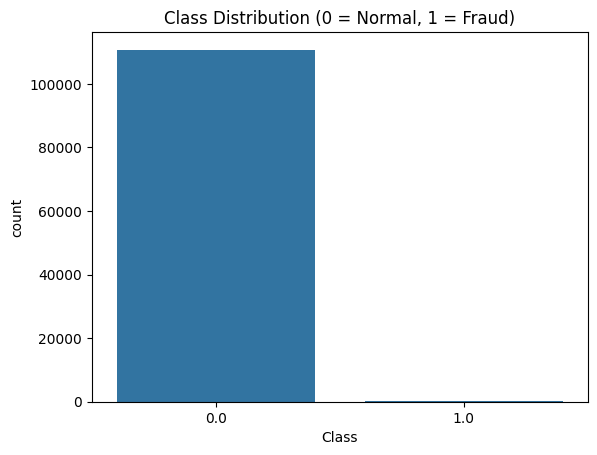

In [9]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print(f"\nFraud cases   : {len(fraud)}")
print(f"Normal cases  : {len(normal)}")

sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

In [10]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df = df.drop(['Time'], axis=1)

In [19]:
from imblearn.over_sampling import SMOTE

X = df.drop('Class', axis=1)
y = df['Class']

In [12]:
!pip install -U imbalanced-learn scikit-learn

In [22]:
nan_indices = y.isna()
X = X[~nan_indices]
y = y[~nan_indices]

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(pd.Series(y_res).value_counts())


After SMOTE:
Class
0.0    110764
1.0    110764
Name: count, dtype: int64


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)


In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.95     21976
         1.0       0.98      0.93      0.95     22330

    accuracy                           0.95     44306
   macro avg       0.95      0.95      0.95     44306
weighted avg       0.95      0.95      0.95     44306


Confusion Matrix:


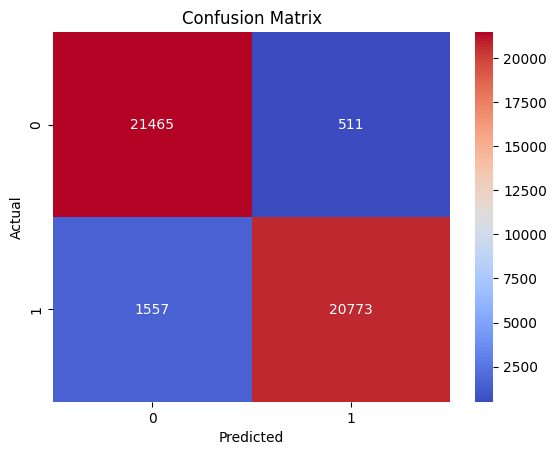

In [26]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
print("\nInsights:")
print("1. Precision: How many predicted frauds are actually fraud")
print("2. Recall   : How many actual frauds we detected")
print("3. F1 Score : Balance between Precision & Recall")


Insights:
1. Precision: How many predicted frauds are actually fraud
2. Recall   : How many actual frauds we detected
3. F1 Score : Balance between Precision & Recall
